In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

import os
import sys
os.chdir("..")

In [2]:
df_listings = pd.read_csv('data/combined_csvs/listings.csv')
df_future = pd.read_csv('data/combined_csvs/future_rates.csv')
df_past = pd.read_csv('data/combined_csvs/past_rates.csv')
df_reviews = pd.read_csv('data/combined_csvs/reviews.csv')

In [3]:
df_listings.columns

Index(['listing_id', 'listing_name', 'description', 'listing_type',
       'room_type', 'cover_photo_url', 'photos_count', 'photo_urls', 'host_id',
       'host_name', 'cohost_ids', 'cohost_names', 'superhost', 'latitude',
       'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration',
       'amenities', 'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'checkin_time', 'checkout_time',
       'guest_favorite', 'exact_location', 'currency', 'cleaning_fee',
       'extra_guest_fee', 'single_fee_structure', 'num_reviews',
       'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_avg_min_nights',
       'ttm_avg_len

In [4]:
df_future.columns

Index(['listing_id', 'date', 'vacant_days', 'reserved_days', 'occupancy',
       'revenue', 'rate_avg', 'booked_rate_avg', 'booking_lead_time_avg',
       'length_of_stay_avg', 'min_nights_avg', 'native_booked_rate_avg',
       'native_rate_avg', 'native_revenue', 'city'],
      dtype='str')

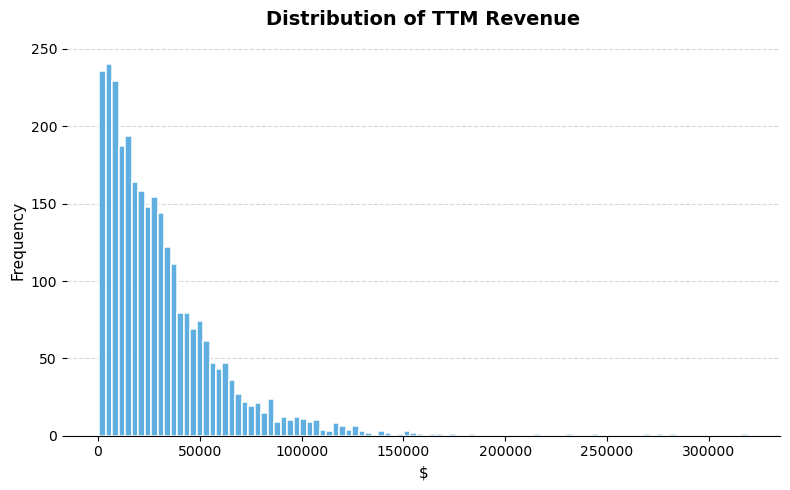

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_listings["ttm_revenue"],
    bins=100,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9,
)

ax.set_title("Distribution of TTM Revenue", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("$", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

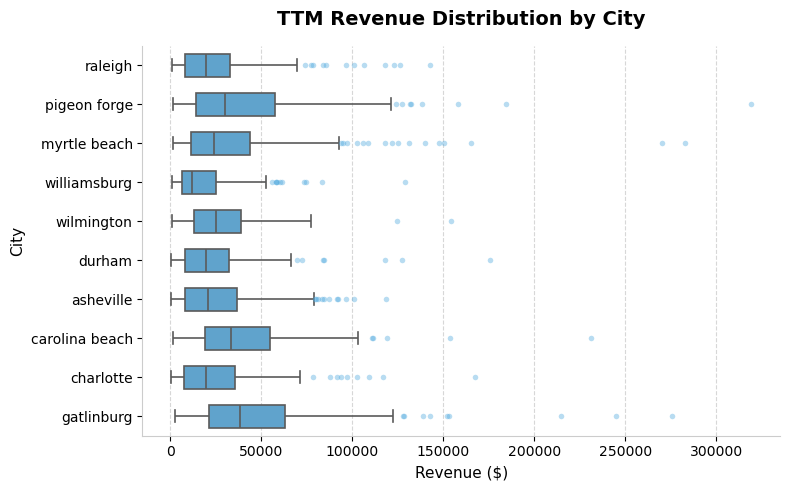

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

# flierprops styles the outlier points to keep them clean and subtle
sns.boxplot(
    data=df_listings,
    x="ttm_revenue",
    y="city",
    ax=ax,
    color="#4EA8DE",
    width=0.6,
    linewidth=1.2,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#4EA8DE",
        "markeredgecolor": "none",
        "alpha": 0.4,
    },
)

ax.set_title(
    "TTM Revenue Distribution by City", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Revenue ($)", fontsize=11)
ax.set_ylabel("City", fontsize=11)

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.show()

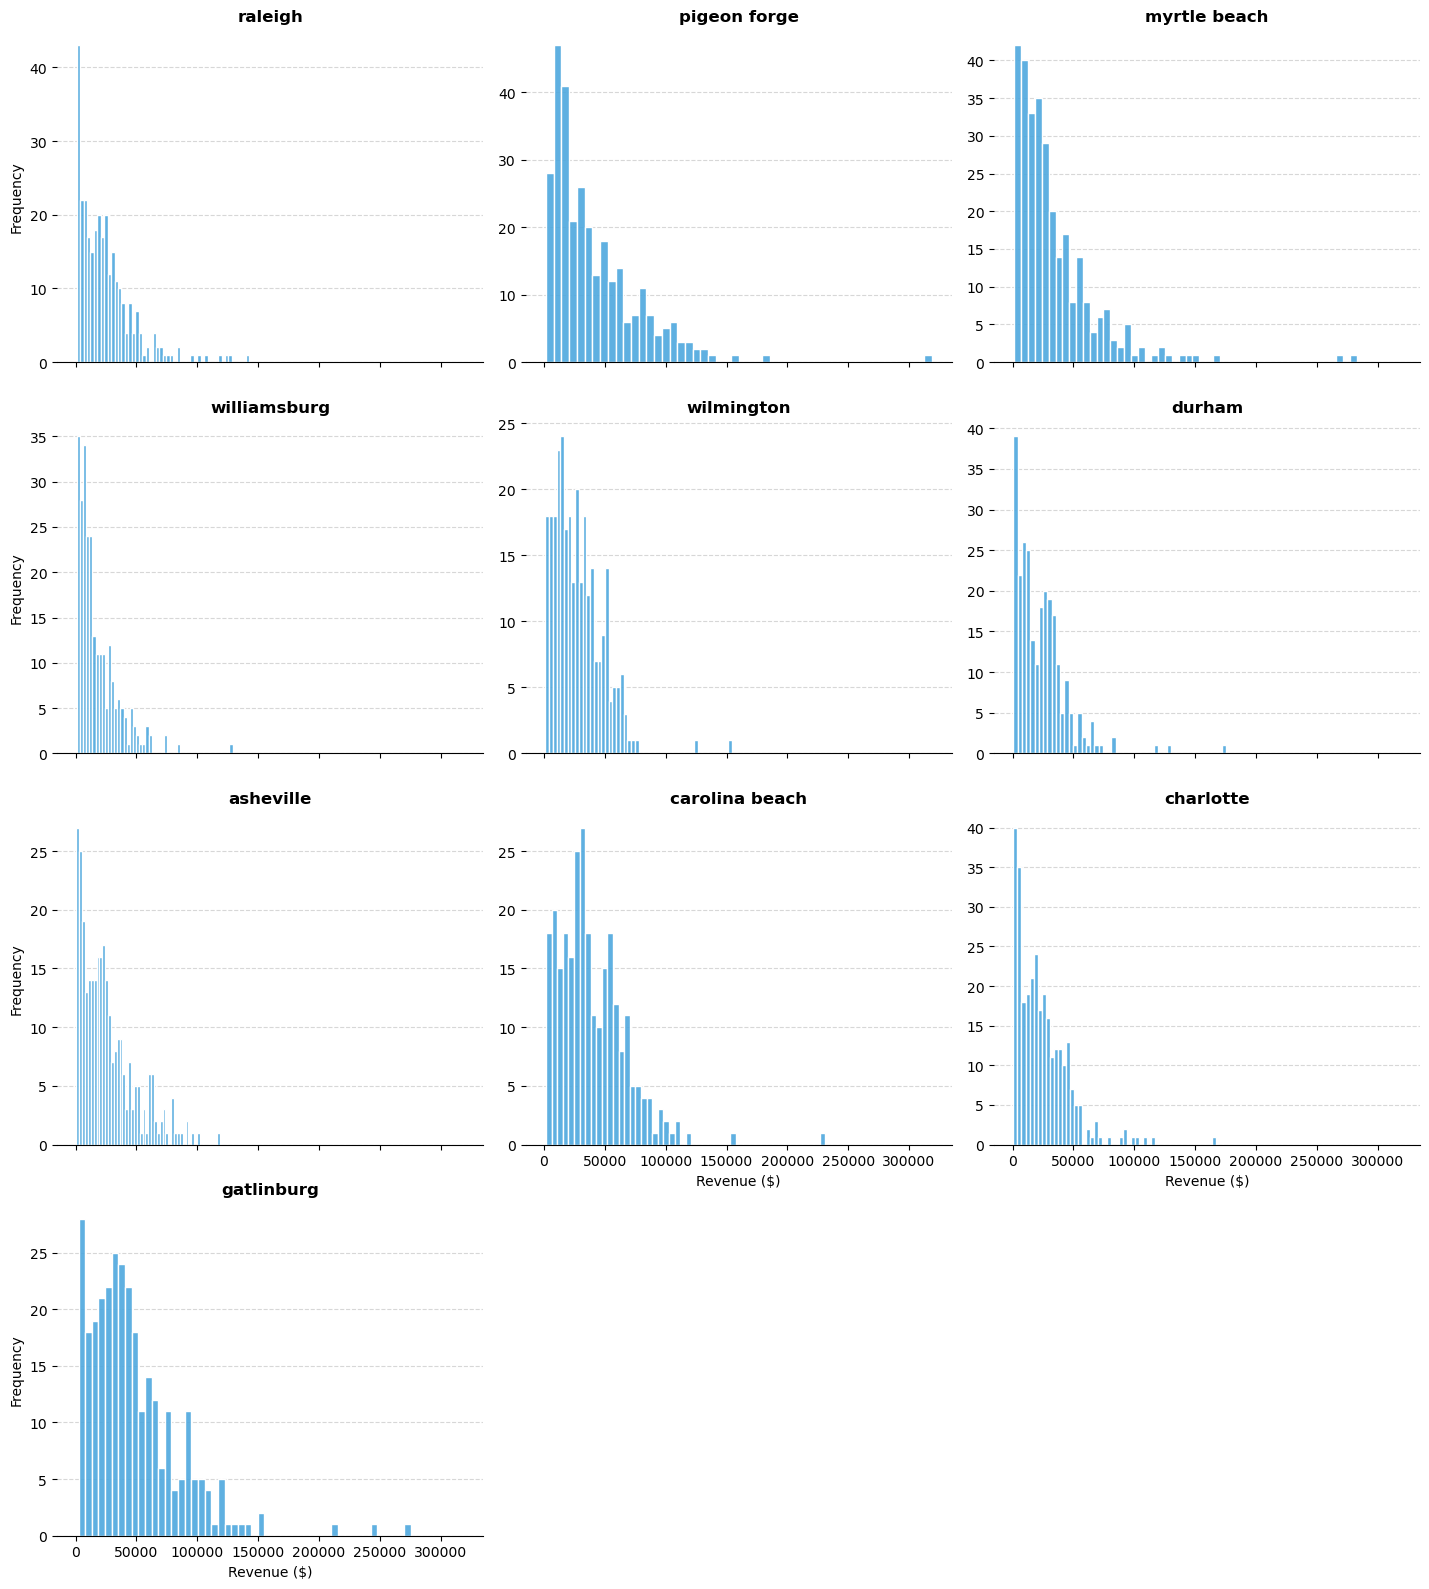

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# This automatically creates a grid of plots based on the number of unique cities
g = sns.FacetGrid(
    df_listings, col="city", col_wrap=3, height=4, aspect=1.2, sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="ttm_revenue",
    bins=50,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1,
    alpha=0.9,
)

g.set_titles(col_template="{col_name}", size=12, weight="bold")
g.set_axis_labels("Revenue ($)", "Frequency")

for ax in g.axes.flat:
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

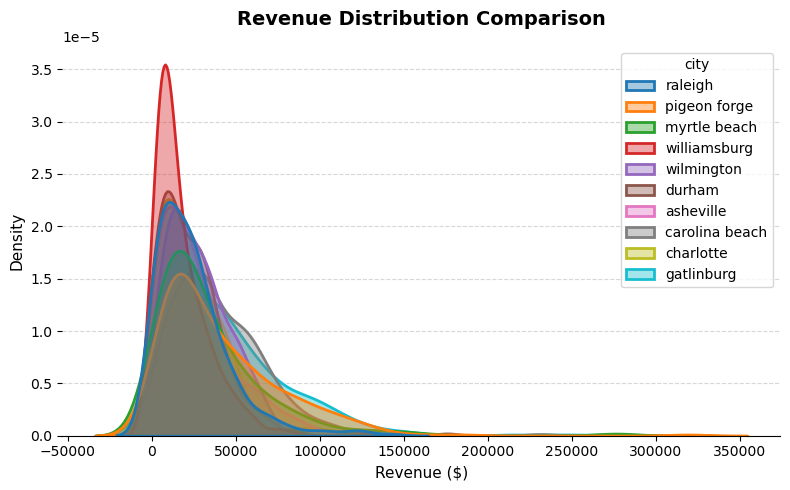

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_listings,
    x="ttm_revenue",
    hue="city",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    ax=ax,
)

ax.set_title(
    "Revenue Distribution Comparison", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Revenue ($)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

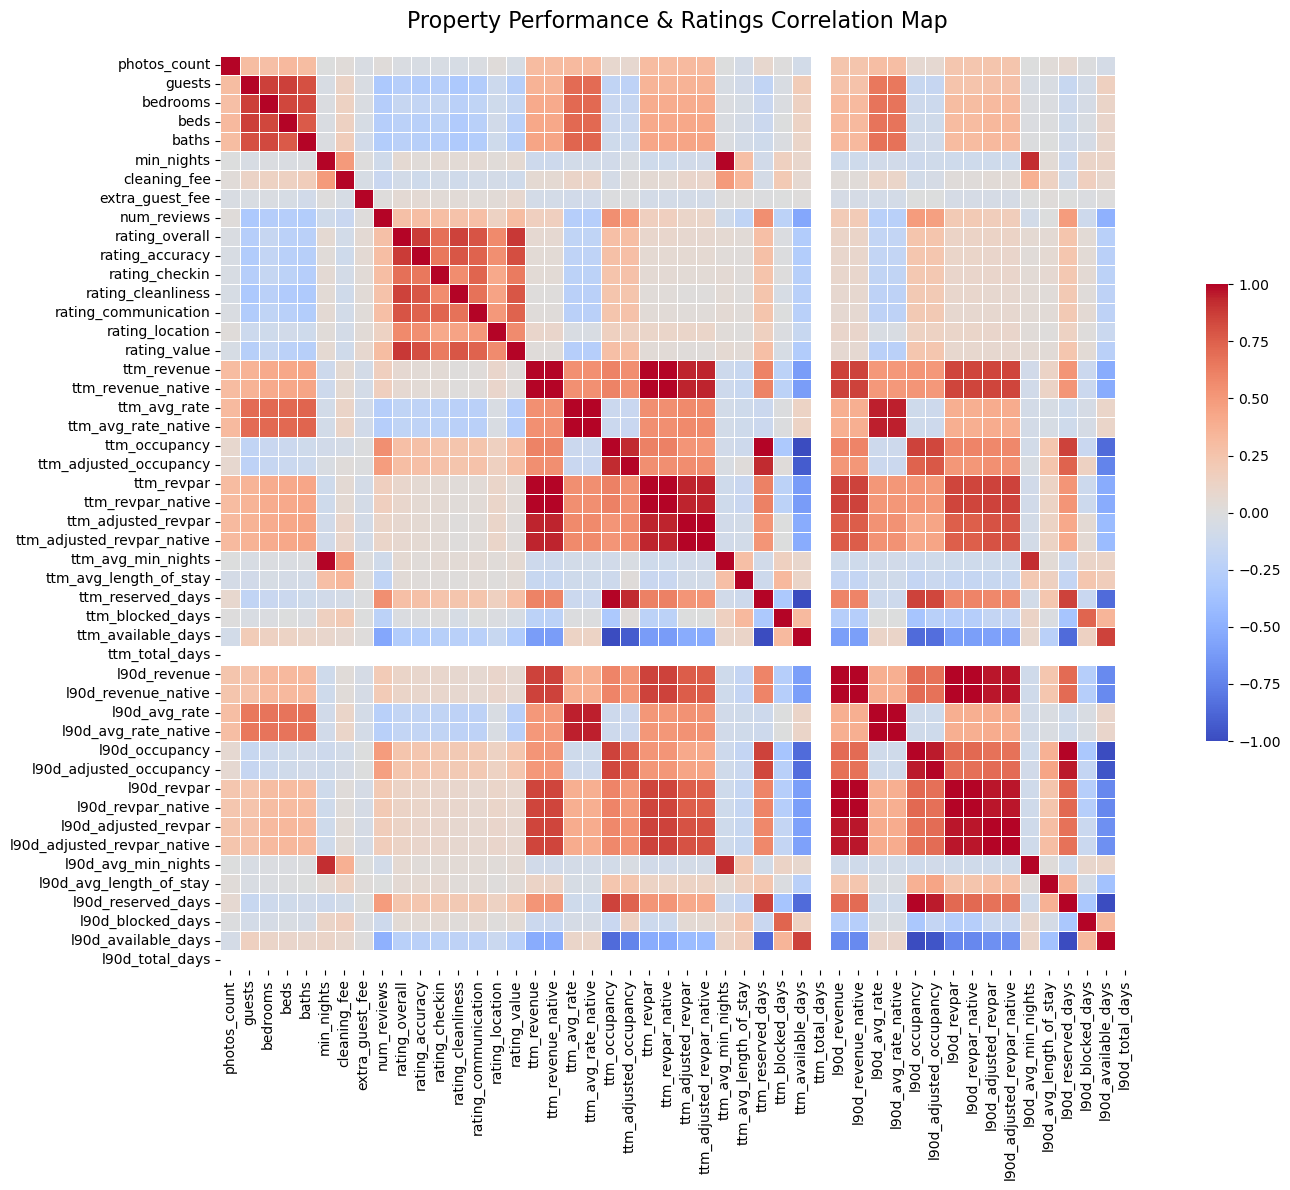

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assuming your dataframe is named 'df'
# 1. Select only the numeric columns to avoid errors
numeric_df = df_listings.select_dtypes(include=["number"])

# Optional: Drop ID columns or coordinates that won't make sense in a correlation map
cols_to_drop = ["listing_id", "host_id", "latitude", "longitude"]
numeric_df = numeric_df.drop(
    columns=[col for col in cols_to_drop if col in numeric_df.columns]
)

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# 4. Generate a mask for the upper triangle (optional, makes it cleaner)
# import numpy as np
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix,
    # mask=mask,                # Uncomment if you want a triangle map
    cmap="coolwarm",  # Good diverging color palette for correlations
    vmax=1,
    vmin=-1,  # Correlation ranges from -1 to 1
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=False,  # Set to True if you want numbers inside squares, but with many columns it gets crowded
    fmt=".2f",
)

plt.title("Property Performance & Ratings Correlation Map", fontsize=16, pad=20)
plt.tight_layout()
plt.show()